<a href="https://colab.research.google.com/github/ricardosilva-boop/Research-Projects/blob/main/Cokriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyvista scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 7.7 MB/s eta 0:00:00


In [ ]:
# Instalar dependências (se necessário)
#!pip install pyvista scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree, ConvexHull, Delaunay
from numpy.linalg import solve
from sklearn.model_selection import KFold
import pyvista as pv
from tqdm import tqdm

# === 1. Ler dados ===
df = pd.read_csv("Cu_Mo_processed.csv")
coords = df[["X", "Y", "Z"]].values
zm = df["Mo"].values  # log(Mo)
zs = df["Cu"].values  # log(Cu)
litho = df["Lithology"].astype(str).values if "Lithology" in df.columns else None

# === 2. Parâmetros variográficos ===
MO_C = np.array([0.295, 0.25, 0.24])
MO_A = np.array([600.0, 500.0, 450.0])  # ajustado
MO_NUGGET = 0.112

CU_C = np.array([0.016, 0.014, 0.010])
CU_A = np.array([600.0, 400.0, 350.0])  # ajustado
CU_NUGGET = 0.008

RHO = 0.645
AZIMUTH_DEG = 157.5
K_MO = 10
K_CU = 10
JITTER = 1e-10

def rotation_matrix(azimuth_deg):
    th = np.deg2rad(azimuth_deg)
    c, s = np.cos(th), np.sin(th)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

R = rotation_matrix(AZIMUTH_DEG)
def to_principal(h): return h @ R.T

def spherical(t): return np.where(t < 1, 1.5*t - 0.5*t**3, 1.0)
def gaussian(t): return 1 - np.exp(-t**2)

def cov_direct(h, C, A, model, nugget=0.0, on_diag=False):
    if on_diag: return np.sum(C) + nugget
    t = np.abs(h) / A
    m = spherical(t) if model == "spherical" else gaussian(t)
    return np.sum(C * (1 - m), axis=-1)

def cov_cross(h, C1, A1, model1, C2, A2, model2, rho):
    t = np.abs(h) / A1
    m = spherical(t) if model1 == "spherical" else gaussian(t)
    coef = rho * np.sqrt(C1 * C2)
    return np.sum(coef * (1 - m), axis=-1)

# === 3. Estimador OKC proporcional ===
def okc_point(x0, Xm, Zm, Xs, Zs, tree_m, tree_s):
    _, idx_m = tree_m.query(x0, k=K_MO)
    _, idx_s = tree_s.query(x0, k=K_CU)
    Xm_loc, Zm_loc = Xm[idx_m], Zm[idx_m]
    Xs_loc, Zs_loc = Xs[idx_s], Zs[idx_s]
    Pm, Ps = len(idx_m), len(idx_s)

    H11 = to_principal(Xm_loc[:, None] - Xm_loc[None])
    C11 = cov_direct(H11, MO_C, MO_A, "spherical")
    np.fill_diagonal(C11, cov_direct(None, MO_C, MO_A, "spherical", MO_NUGGET, True))

    H22 = to_principal(Xs_loc[:, None] - Xs_loc[None])
    C22 = cov_direct(H22, CU_C, CU_A, "gaussian")
    np.fill_diagonal(C22, cov_direct(None, CU_C, CU_A, "gaussian", CU_NUGGET, True))

    H12 = to_principal(Xm_loc[:, None] - Xs_loc[None])
    C12 = cov_cross(H12, MO_C, MO_A, "spherical", CU_C, CU_A, "gaussian", RHO)
    C21 = C12.T

    K = np.block([[C11, C12], [C21, C22]])
    A = np.zeros((Pm + Ps + 2, Pm + Ps + 2))
    A[:Pm+Ps, :Pm+Ps] = K
    A[:Pm, Pm+Ps] = 1.0; A[Pm+Ps, :Pm] = 1.0
    A[Pm:Pm+Ps, Pm+Ps+1] = 1.0; A[Pm+Ps+1, Pm:Pm+Ps] = 1.0

    hm = to_principal(Xm_loc - x0)
    hs = to_principal(Xs_loc - x0)
    c1_star = cov_direct(hm, MO_C, MO_A, "spherical")
    c2_star = cov_cross(hs, MO_C, MO_A, "spherical", CU_C, CU_A, "gaussian", RHO)
    b = np.zeros(Pm + Ps + 2)
    b[:Pm] = c1_star
    b[Pm:Pm+Ps] = c2_star
    b[Pm+Ps] = 1.0
    b[Pm+Ps+1] = 0.0

    A[:Pm+Ps, :Pm+Ps] += JITTER * np.eye(Pm + Ps)
    w = solve(A, b)[:Pm+Ps]
    m_hat = np.dot(w[:Pm], Zm_loc) + np.dot(w[Pm:], Zs_loc)
    s2 = cov_direct(None, MO_C, MO_A, "spherical", MO_NUGGET, True) - (np.dot(c1_star, w[:Pm]) + np.dot(c2_star, w[Pm:]))
    return float(m_hat), float(max(s2, 1e-12))


In [ ]:
# === 4. Grade 3D + máscara ===
CELL_X, CELL_Y, CELL_Z = 25, 25, 25
PADDING = 0.2
(xmin, ymin, zmin), (xmax, ymax, zmax) = coords.min(0), coords.max(0)
xg = np.arange(xmin - PADDING*(xmax-xmin), xmax + CELL_X, CELL_X)
yg = np.arange(ymin - PADDING*(ymax-ymin), ymax + CELL_Y, CELL_Y)
zg = np.arange(zmin - PADDING*(zmax-zmin), zmax + CELL_Z, CELL_Z)
XX, YY, ZZ = np.meshgrid(xg, yg, zg, indexing='ij')
grid_pts = np.column_stack([XX.ravel(), YY.ravel(), ZZ.ravel()])

hull = ConvexHull(coords)
mask = Delaunay(coords[hull.vertices]).find_simplex(grid_pts) >= 0
masked_pts = grid_pts[mask]

# === 5. Estimar nos nós da máscara ===
tree_m = cKDTree(coords)
tree_s = cKDTree(coords)
m_log, v_log = [], []

for pt in tqdm(masked_pts, desc="Estimando blocos"):
    m, s2 = okc_point(pt, coords, zm, coords, zs, tree_m, tree_s)
    m_log.append(m)
    v_log.append(s2)

m_log = np.array(m_log)
v_log = np.array(v_log)
mo_est = np.exp(m_log + 0.5 * v_log)

df_blocks = pd.DataFrame({
    "Xc": masked_pts[:, 0],
    "Yc": masked_pts[:, 1],
    "Zc": masked_pts[:, 2],
    "Mo_est_original": mo_est,
    "Mo_est_log": m_log,
    "Var_log": v_log
})
df_blocks.to_csv("modelo_blocos_deswik.csv", index=False)
print("CSV para Deswik salvo.")

# === 6. Exportar VTK ===
x_unique = np.sort(df_blocks["Xc"].unique())
y_unique = np.sort(df_blocks["Yc"].unique())
z_unique = np.sort(df_blocks["Zc"].unique())
nx, ny, nz = len(x_unique), len(y_unique), len(z_unique)
dx = x_unique[1] - x_unique[0]
dy = y_unique[1] - y_unique[0]
dz = z_unique[1] - z_unique[0]

Estimando blocos: 100%|██████████| 268593/268593 [02:32<00:00, 1762.30it/s]


CSV para Deswik salvo.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Carregar dados ===
df_blocos = pd.read_csv("modelo_blocos_deswik.csv")
df_furos = pd.read_csv("Cu_Mo_processed.csv")

# === 2. Associar furos aos blocos mais próximos ===
from scipy.spatial import cKDTree

# Filtrar linhas com NaN nas colunas de coordenadas antes de criar o KDTree
df_blocos_filtered = df_blocos.dropna(subset=["Xc", "Yc", "Zc"])
tree_blocos = cKDTree(df_blocos_filtered[["Xc", "Yc", "Zc"]].values)
furos_coords = df_furos[["X", "Y", "Z"]].values
idx_nearest = tree_blocos.query(furos_coords, k=1)[1]

# === 3. Comparar estimativas com valores reais ===
mo_real_log = df_furos["Mo"].values
# Usar o DataFrame filtrado para obter as estimativas correspondentes
mo_est_log = df_blocos_filtered.iloc[idx_nearest]["Mo_est_log"].values
var_log = df_blocos_filtered.iloc[idx_nearest]["Var_log"].values
mo_est_orig = np.exp(mo_est_log + 0.5 * var_log)
mo_real_orig = np.exp(mo_real_log)

In [ ]:
# === 4. Métricas ===
resid_log = mo_real_log - mo_est_log
rmse_log = np.sqrt(np.mean(resid_log**2))
me_log = np.mean(resid_log)
corr_log = np.corrcoef(mo_real_log, mo_est_log)[0, 1]

resid_orig = mo_real_orig - mo_est_orig
rmse_orig = np.sqrt(np.mean(resid_orig**2))
me_orig = np.mean(resid_orig)
corr_orig = np.corrcoef(mo_real_orig, mo_est_orig)[0, 1]

print("\n=== MÉTRICAS DO MODELO DE BLOCO ===")
print(f"[LOG]     RMSE: {rmse_log:.4f} | ME: {me_log:.4f} | Corr: {corr_log:.4f}")
print(f"[ORIGINAL] RMSE: {rmse_orig:.4f} | ME: {me_orig:.4f} | Corr: {corr_orig:.4f}")



=== MÉTRICAS DO MODELO DE BLOCO ===
[LOG]     RMSE: 0.2930 | ME: -0.0002 | Corr: 0.8195
[ORIGINAL] RMSE: 0.0339 | ME: -0.0002 | Corr: 0.6784


In [ ]:
# === 8. Calcular e exibir R-quadrado ===
r2_log = corr_log**2
r2_orig = corr_orig**2

print(f"[LOG]     R-quadrado: {r2_log:.4f}")
print(f"[ORIGINAL] R-quadrado: {r2_orig:.4f}")

[LOG]     R-quadrado: 0.6715
[ORIGINAL] R-quadrado: 0.4602


In [ ]:
from scipy.stats import skew, kurtosis

# === 9. Calcular e exibir assimetria e curtose ===
skewness_log = skew(resid_log)
kurtosis_log = kurtosis(resid_log)

skewness_orig = skew(resid_orig)
kurtosis_orig = kurtosis(resid_orig)

print("\n=== COEFICIENTES DE ASSIMETRIA E CURTOSE ===")
print(f"[LOG]     Assimetria: {skewness_log:.4f} | Curtose: {kurtosis_log:.4f}")
print(f"[ORIGINAL] Assimetria: {skewness_orig:.4f} | Curtose: {kurtosis_orig:.4f}")


=== COEFICIENTES DE ASSIMETRIA E CURTOSE ===
[LOG]     Assimetria: 1.0491 | Curtose: 3.7697
[ORIGINAL] Assimetria: 8.3935 | Curtose: 120.5988


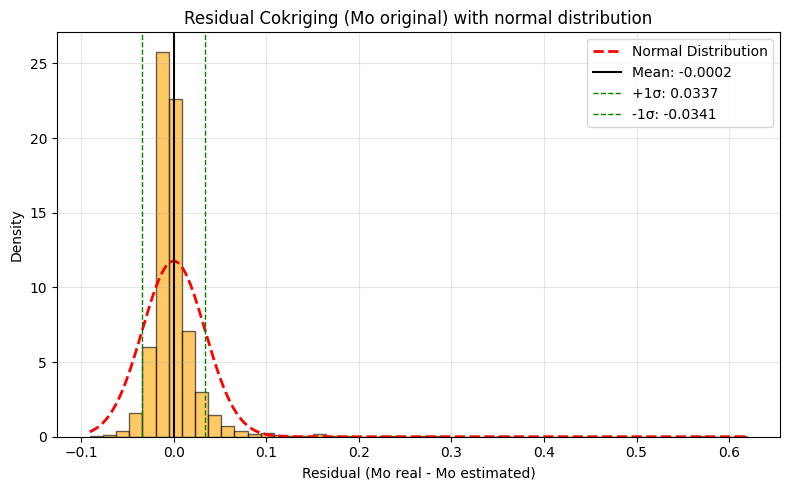

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# === Estatísticas básicas ===
mu = np.mean(resid_orig)
sigma = np.std(resid_orig)

# === Histograma com curva normal ===
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(resid_orig, bins=50, density=True, color='orange', edgecolor='k', alpha=0.6)

# Curva normal teórica
x = np.linspace(min(resid_orig), max(resid_orig), 1000)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Normal Distribution')

# Linhas de média e desvio padrão
plt.axvline(mu, color='black', linestyle='-', linewidth=1.5, label=f'Mean: {mu:.4f}')
plt.axvline(mu + sigma, color='green', linestyle='--', linewidth=1, label=f'+1σ: {mu+sigma:.4f}')
plt.axvline(mu - sigma, color='green', linestyle='--', linewidth=1, label=f'-1σ: {mu-sigma:.4f}')

# Estética
plt.title("Residual Cokriging (Mo original) with normal distribution")
plt.xlabel("Residual (Mo real - Mo estimated)")
plt.ylabel("Density")
plt.legend(loc='upper right') # Placing legend inside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Residual_Cokrig_Mo_original_ND_legend_inside.pdf", bbox_inches="tight", format="pdf")
plt.show()


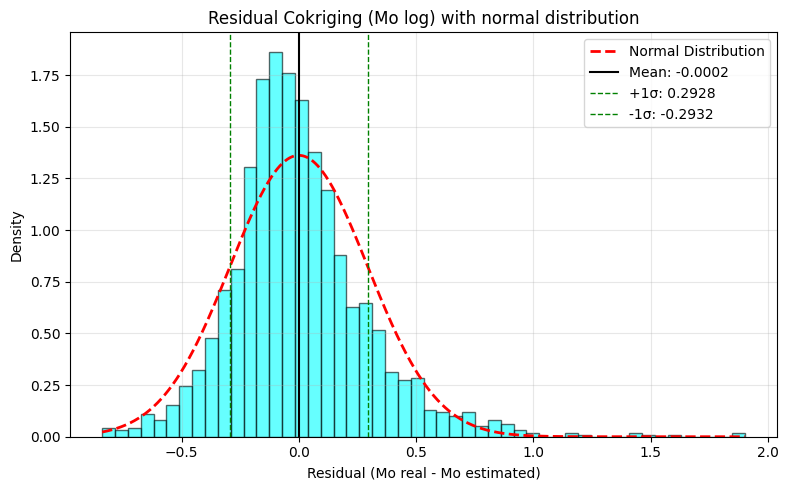

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# === 1. Estatísticas dos resíduos log ===
mu_log = np.mean(resid_log)
sigma_log = np.std(resid_log)

# === 2. Histograma com curva normal ===
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(resid_log, bins=50, density=True, color='aqua', edgecolor='k', alpha=0.6)

# Curva normal teórica
x = np.linspace(min(resid_log), max(resid_log), 1000)
plt.plot(x, norm.pdf(x, mu_log, sigma_log), 'r--', linewidth=2, label='Normal Distribution')

# Linhas de média e desvio padrão
plt.axvline(mu_log, color='black', linestyle='-', linewidth=1.5, label=f'Mean: {mu_log:.4f}')
plt.axvline(mu_log + sigma_log, color='green', linestyle='--', linewidth=1, label=f'+1σ: {mu_log + sigma_log:.4f}')
plt.axvline(mu_log - sigma_log, color='green', linestyle='--', linewidth=1, label=f'-1σ: {mu_log - sigma_log:.4f}')

# Estética
plt.title("Residual Cokriging (Mo log) with normal distribution")
plt.xlabel("Residual (Mo real - Mo estimated)")
plt.ylabel("Density")
plt.legend(loc='upper right') # Placing legend inside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Residual_Cokrig_Mo_log_ND_legend_inside.pdf", bbox_inches="tight", format="pdf")
plt.show()

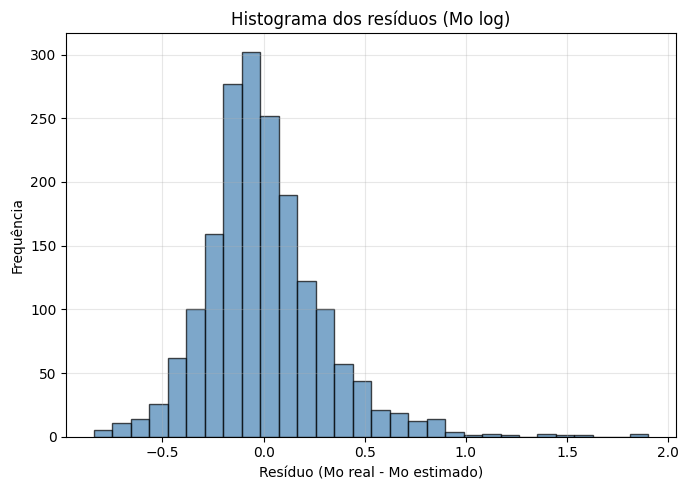

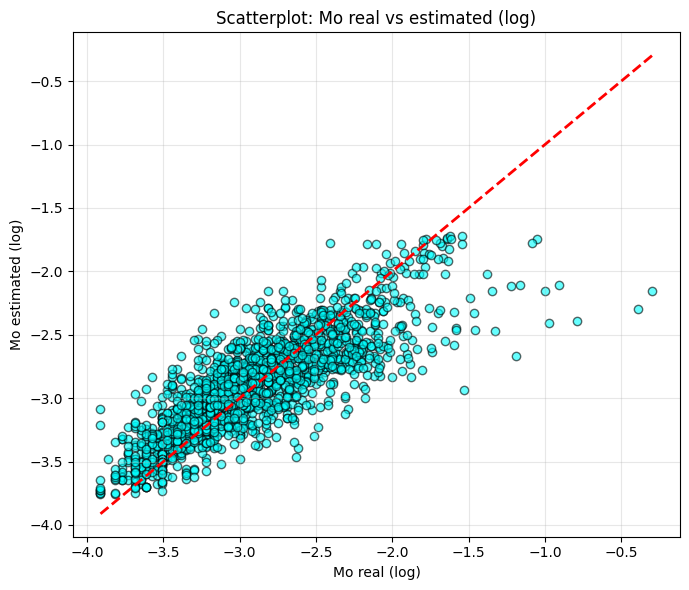

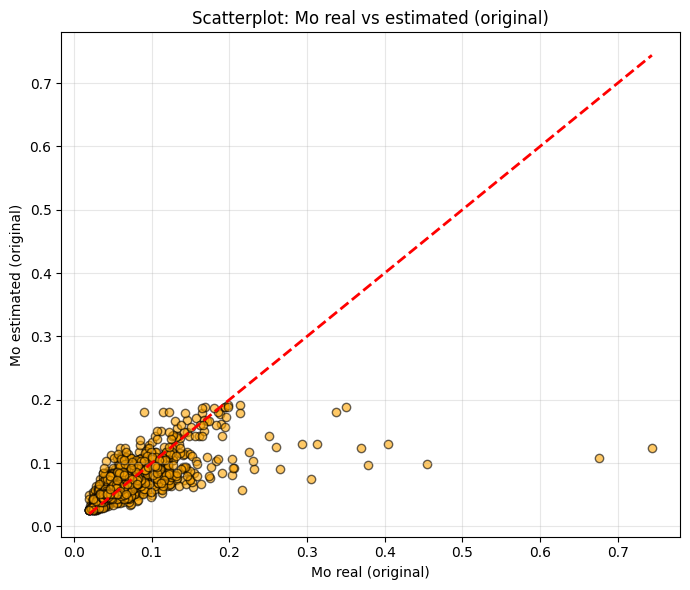

In [ ]:
# === 5. Histograma dos resíduos (log) ===
plt.figure(figsize=(7,5))
plt.hist(resid_log, bins=30, color='steelblue', edgecolor='k', alpha=0.7)
plt.title("Histograma dos resíduos (Mo log)")
plt.xlabel("Resíduo (Mo real - Mo estimado)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 6. Dispersão real vs estimado (log) ===
plt.figure(figsize=(7,6))
plt.scatter(mo_real_log, mo_est_log, color='aqua', alpha=0.6, edgecolor='k')
plt.plot([mo_real_log.min(), mo_real_log.max()], [mo_real_log.min(), mo_real_log.max()], 'r--', lw=2)
plt.xlabel("Mo real (log)")
plt.ylabel("Mo estimated (log)")
plt.title("Scatterplot: Mo real vs estimated (log)")
plt.savefig("scatterplot_Mo real vs estimated (log).pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === 7. Dispersão real vs estimado (original) ===
plt.figure(figsize=(7,6))
plt.scatter(mo_real_orig, mo_est_orig, color='orange', alpha=0.6, edgecolor='k')
plt.plot([mo_real_orig.min(), mo_real_orig.max()], [mo_real_orig.min(), mo_real_orig.max()], 'r--', lw=2)
plt.xlabel("Mo real (original)")
plt.ylabel("Mo estimated (original)")
plt.title("Scatterplot: Mo real vs estimated (original)")
plt.savefig("scatterplot_Mo real vs estimated (original).pdf", bbox_inches="tight", format="pdf")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()